
# **EQ03 : vol locale vs Heston sur données réelles (AAPL)**

Les deux premiers notebooks equity travaillaient sur des surfaces générées par un
Heston de référence : le marché était propre, sans arbitrage, connu à la décimale.
Ici on refait toute la chaîne sur un vrai marché : une chaîne d'options AAPL
téléchargée de yfinance, avec ses spreads, ses quotes mortes et ses incohérences.

Le programme est celui d'un desk qui met en place un nouveau sous-jacent :

1. extraire de la strip de vanilles une courbe forward et une courbe de discount
   qui se tiennent (parité put-call) ;
2. construire la surface de vol implicite et la lisser (SVI) ;
3. calibrer une vol locale de Dupire et vérifier qu'elle reprice les vanilles ;
4. calibrer un Heston sur la même surface, vérifier de même ;
5. pricer un exotique path-dependent (call up-and-out) dans les deux modèles et
   comprendre d'où vient l'écart.

> La thèse ne change pas depuis le notebook précédent : deux modèles calibrés sur
> les mêmes vanilles peuvent donner des prix d'exotique différents, parce qu'ils
> ne font pas vivre le smile de la même façon quand le spot bouge. La nouveauté,
> c'est que plus rien n'est synthétique : chaque étape doit maintenant survivre à
> des données bruitées, et chaque choix de nettoyage ou de calibration est un
> vrai choix, qu'on documente au fur et à mesure.

Les données viennent du snapshot committé dans `data/` (produit par le notebook
`DATA_01_download_aapl`). Ce notebook ne touche jamais au réseau : relancer toutes
les cellules redonne exactement les mêmes chiffres.


In [1]:

from datetime import timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from JR_PRICER.market_data.loaders.option_chain import ChainQualityFilter, OptionChainSnapshot
from JR_PRICER.market_data.quote import Quote
from JR_PRICER.market_data.underlying import Underlying
from JR_PRICER.utils.day_count import DayCounter
from JR_PRICER.utils.frequency import Frequency

from JR_PRICER.curves.builder.parity_builder import (
    PutCallParityCurveBuilder, StrikeWindow, UniformWeights, InverseSpreadWeights)
from JR_PRICER.curves.builder.regression import WeightedLeastSquares, MADRejectionRegression
from JR_PRICER.curves.forward.market_forward import MarketForwardCurve
from JR_PRICER.curves.interpolators_1D.log_linear import LogLinearInterpolator1D

from JR_PRICER.curves.vol_smile.volsmile import VolSmile
from JR_PRICER.curves.vol_smile.moneyness_convention import AbsoluteStrike
from JR_PRICER.surfaces.vol_surface.volsurface import VolSurface
from JR_PRICER.surfaces.vol_surface.interpolators_2D.SVI import SVIInterpolator

from JR_PRICER.instruments.derivatives.equity.european_option import EuropeanOption
from JR_PRICER.instruments.derivatives.equity.base import OptionType
from JR_PRICER.instruments.derivatives.equity.barrier_option import (
    BarrierOption, BarrierType, BarrierDirection)

from JR_PRICER.pricing.model.local_vol import LocalVolModel
from JR_PRICER.pricing.model.heston import HestonModel
from JR_PRICER.pricing.model.discretization.CIR.base import (
    CIRDiscretizationSchemeEuler, EulerDiscretizationConvention)
from JR_PRICER.pricing.engine.fourier_carr_madan import FourierCarrMadanEngine
from JR_PRICER.pricing.engine.monte_carlo import MCEngine
from JR_PRICER.pricing.implied_vol_calculator import ImpliedVolCalculator
from JR_PRICER.pricing.formulas import black_forward_price

from JR_PRICER.calibration.calibrate import calibrate
from JR_PRICER.calibration.cost_function.model.implied_vol_cost import ImpliedVolErrorCost
from JR_PRICER.calibration.optimizer.least_squares import SciPyOLSOptimizer

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
C_LV, C_HE, C_MKT, C_SK = '#E65100', '#1565C0', '#C62828', '#2E7D32'

CSV_PATH = Path("data") / "aapl_option_chain_2026-07-02.csv"



## 0. La matière première : une chaîne d'options brute

Le snapshot contient, pour chaque option listée : bid, ask, dernier prix traité,
volume du jour, open interest, et la vol implicite indicative de Yahoo. On charge
tout tel quel, sans filtrage : la première chose à faire avec des données de
marché est de les regarder.


In [2]:

snap = OptionChainSnapshot.from_csv(CSV_PATH)
REF = snap.quote_date          # date de valorisation = date du snapshot
S0 = snap.spot.value()
DC = DayCounter('act/365')

chain = snap.chain
print(snap)
print(f"spot : {S0:.2f} au {REF}")
chain.head()


OptionChainSnapshot(quote_date=2026-07-02, spot=305.7001037597656, n_rows=1898, n_expiries=15)
spot : 305.70 au 2026-07-02


,expiry,option_type,strike,bid,ask,last,volume,open_interest,iv_yf
0,2026-07-10,C,130.0,172.65,175.80,160.40,NaN,1,2.105473
1,2026-07-10,C,155.0,147.65,150.95,125.60,2.0,1,1.896485
2,2026-07-10,C,185.0,117.65,120.90,97.58,1.0,1,1.400394
3,2026-07-10,C,195.0,107.75,111.15,94.42,1.0,2,1.424808
4,2026-07-10,C,200.0,102.70,105.75,76.24,1.0,2,1.019536


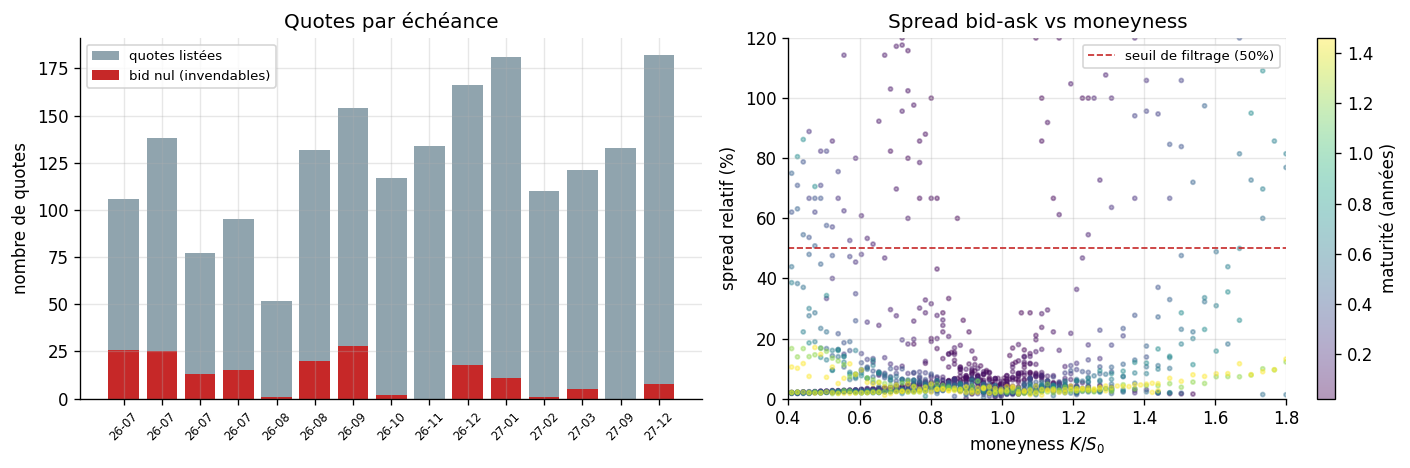

quotes two-sided : 1723/1898 (91%)
spread relatif médian ATM (0.95-1.05) : 3.0%


In [3]:

# Deux vues de la qualité de la chaîne : combien de quotes par échéance, et
# comment le spread bid-ask se dégrade quand on s'éloigne de la monnaie.
two_sided = chain[(chain.bid > 0) & (chain.ask > chain.bid)].copy()
two_sided['mid'] = (two_sided.bid + two_sided.ask) / 2
two_sided['rel_spread'] = (two_sided.ask - two_sided.bid) / two_sided.mid
two_sided['moneyness'] = two_sided.strike / S0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

counts = chain.groupby('expiry').size()
dead = (chain.bid <= 0).groupby(chain.expiry).sum()
ax1.bar(range(len(counts)), counts.values, color='#90A4AE', label='quotes listées')
ax1.bar(range(len(counts)), dead.reindex(counts.index).values, color=C_MKT,
        label='bid nul (invendables)')
ax1.set_xticks(range(len(counts)))
ax1.set_xticklabels([d.strftime('%y-%m') for d in counts.index], rotation=45, fontsize=7)
ax1.set_ylabel('nombre de quotes')
ax1.set_title('Quotes par échéance')
ax1.legend(fontsize=8)

sc = ax2.scatter(two_sided.moneyness, two_sided.rel_spread * 100, s=6, alpha=0.4,
                 c=[(d - REF).days / 365 for d in two_sided.expiry], cmap='viridis')
ax2.axhline(50, color=C_MKT, ls='--', lw=1, label='seuil de filtrage (50%)')
ax2.set_xlim(0.4, 1.8); ax2.set_ylim(0, 120)
ax2.set_xlabel('moneyness $K/S_0$'); ax2.set_ylabel('spread relatif (%)')
ax2.set_title('Spread bid-ask vs moneyness')
plt.colorbar(sc, ax=ax2, label='maturité (années)')
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"quotes two-sided : {len(two_sided)}/{len(chain)} "
      f"({len(two_sided)/len(chain)*100:.0f}%)")
print(f"spread relatif médian ATM (0.95-1.05) : "
      f"{two_sided[abs(two_sided.moneyness-1) < 0.05].rel_spread.median()*100:.1f}%")



Le tableau est typique d'un single name liquide : la monnaie cote serré (quelques
pourcents de spread relatif), les ailes s'élargissent vite, et une fraction non
négligeable des lignes n'a tout simplement pas de bid. Environ 9% des quotes sont
mortes ou croisées, et on n'a encore rien filtré sur le volume.

D'où une règle d'hygiène avant toute utilisation : on ne garde que les quotes
two-sided (bid strictement positif, ask au-dessus du bid), avec un prix minimal,
un spread relatif borné et un open interest non nul. Ces filtres vivent dans
`ChainQualityFilter` et s'appliquent leg par leg, avant même de parler de modèle.
Le mid est toujours `(bid + ask) / 2` : le dernier prix traité peut dater de
plusieurs heures et mélange des instants de marché différents.



## 1. Forward et discount par parité put-call

Avant de parler de volatilité, il faut savoir ce que le marché pense du forward
et de l'actualisation. Pour un sous-jacent equity on n'observe ni l'un ni
l'autre directement, mais les options les portent tous les deux. Pour des
options européennes, à chaque maturité :

$$C(K, T) - P(K, T) = D(0, T)\,F(0, T) - D(0, T)\,K$$

La différence call moins put est une fonction affine du strike, quelle que soit
la surface de vol. Une régression de $C - P$ sur $K$ donne donc, par maturité :

- la pente, qui vaut $-D(0, T)$ : le discount factor implicite ;
- l'ordonnée à l'origine, qui vaut $D(0, T)\,F(0, T)$ : combinée à la pente,
  elle donne le forward.

Les deux courbes sortent de la même régression, elles sont donc cohérentes entre
elles par construction. C'est le point qui compte pour la suite : toute la
calibration (vols implicites, Dupire, Heston) se fera dans cette mesure là.

Sur données réelles, la droite est polluée et le builder expose trois défenses,
qui correspondent à ce qu'on ferait à la main :

- une pondération par l'inverse du spread bid-ask, pour que les quotes liquides
  de la monnaie dominent les ailes larges ;
- une régression robuste (fit, rejet des résidus aberrants au-delà de 3 fois
  l'écart robuste, refit) qui écarte les quotes fausses au lieu de les moyenner ;
- une fenêtre de strikes en deux passes : premier fit sur tout, estimation du
  forward, puis refit sur $K \in [0.85\,\hat F, 1.15\,\hat F]$.

La fenêtre mérite une explication, parce qu'elle répond à un vrai problème :
les options AAPL sont américaines, et la parité stricte ne vaut que pour des
européennes. La prime d'exercice anticipé gonfle surtout les puts très dans la
monnaie (exercer libère du cash qui porte intérêt) et les calls dans la monnaie
avant détachement de dividende. Près du forward, elle est de second ordre.
Restreindre la régression autour de la monnaie ne corrige pas le biais, mais le
réduit là où il est le plus fort, sans modèle supplémentaire.


In [4]:

quotes = snap.to_put_call_quotes(ChainQualityFilter())
print(f"{len(quotes)} paires call/put apres filtres et appariement")

builder = PutCallParityCurveBuilder(
    day_count_convention=DC,
    discount_interpolator=LogLinearInterpolator1D(),   # log-lineaire sur les DF
    forward_interpolator=LogLinearInterpolator1D(),    # carry constant par morceaux
    weighting=InverseSpreadWeights(),
    regression=MADRejectionRegression(k_mad=3.0),
    strike_window=StrikeWindow(0.85, 1.15),
)
curves = builder.build(quotes, snap.spot, REF)
disc, fwd = curves.discount_curve, curves.forward_curve

for w in curves.warnings:
    print("warning :", w)

tab = pd.DataFrame(curves.diagnostics_table())
tab.style.format({'maturity': '{:.3f}', 'discount_factor': '{:.5f}', 'forward': '{:.2f}',
                  'zero_rate': '{:+.2%}', 'implied_carry': '{:+.2%}', 'r_squared': '{:.5f}',
                  'rmse': '{:.3f}', 'stderr_forward': '{:.2f}'})


508 paires call/put apres filtres et appariement


,maturity,maturity_date,n_quotes_input,n_quotes_used,discount_factor,forward,zero_rate,implied_carry,r_squared,rmse,stderr_forward,window_applied
0,0.022,2026-07-10,22,22,0.99146,304.47,+39.13%,+57.58%,0.99972,0.215,1.60,True
1,0.041,2026-07-17,28,23,0.99758,304.67,+5.89%,+14.09%,0.99970,0.248,1.62,True
2,0.060,2026-07-24,15,13,0.99360,304.81,+10.66%,+15.52%,0.99954,0.324,2.74,True
3,0.079,2026-07-31,17,12,0.99228,305.08,+9.75%,+12.31%,0.99989,0.157,1.41,True
4,0.099,2026-08-07,18,12,0.99440,305.17,+5.70%,+7.46%,0.99988,0.187,1.46,True
5,0.137,2026-08-21,29,17,1.00653,305.41,-4.75%,-4.05%,0.99977,0.300,1.66,True
6,0.214,2026-09-18,36,18,1.00390,306.40,-1.82%,-2.89%,0.99983,0.264,1.42,True
7,0.290,2026-10-16,35,17,1.00270,307.34,-0.93%,-2.77%,0.99986,0.243,1.30,True
8,0.386,2026-11-20,39,18,0.99639,308.32,+0.94%,-1.27%,0.99974,0.358,1.75,True
9,0.463,2026-12-18,43,18,0.99750,309.18,+0.54%,-1.90%,0.99987,0.263,1.25,True


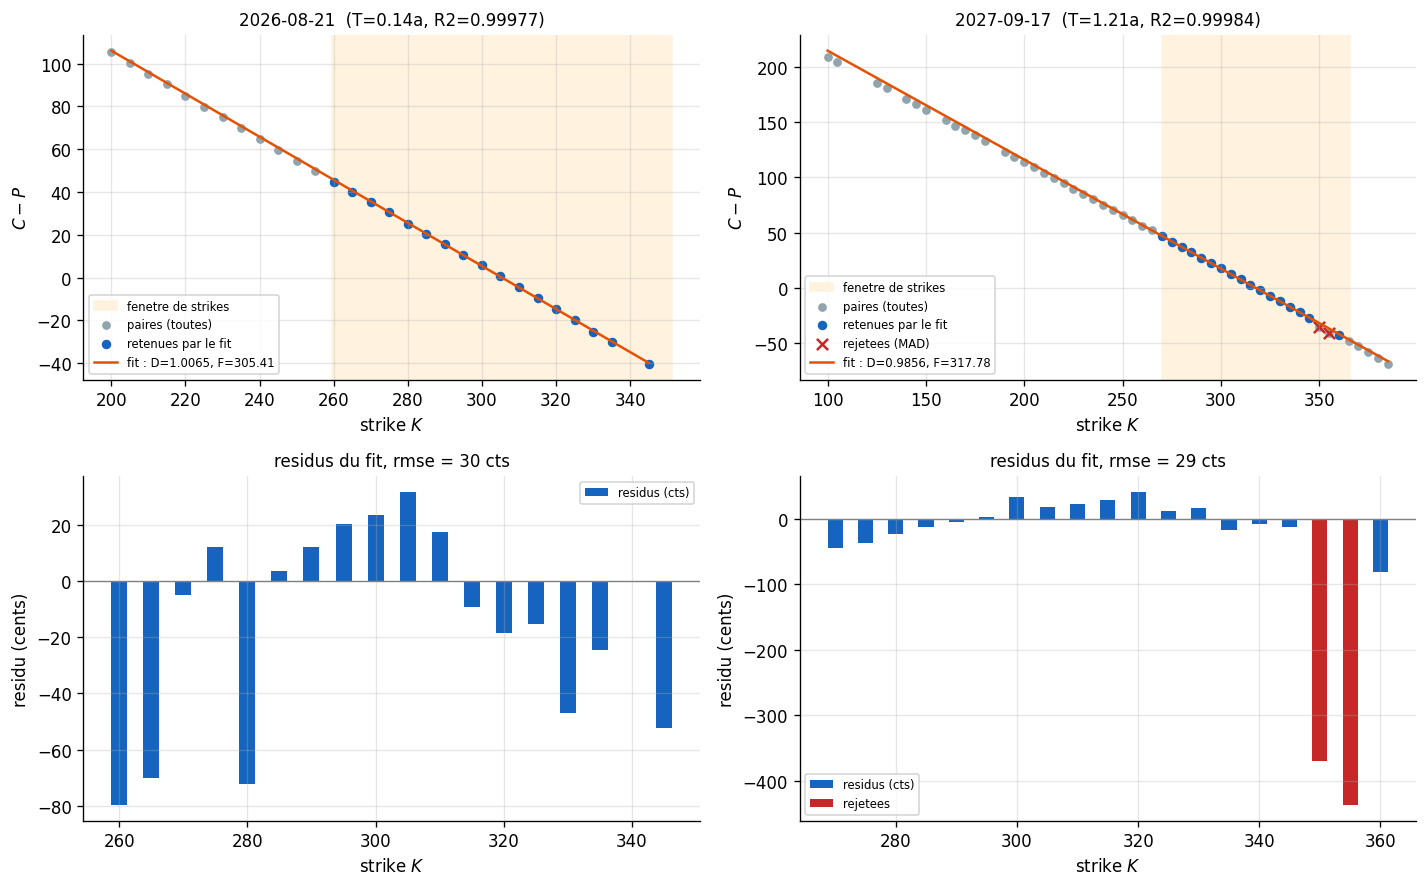

In [5]:

# La régression vue de près sur deux échéances : la droite de parité, les quotes
# retenues et rejetées, la fenêtre de strikes, puis les résidus.
from datetime import date
show_expiries = [date(2026, 8, 21), date(2027, 9, 17)]

fig, axes = plt.subplots(2, 2, figsize=(12, 7.5))
for j, exp in enumerate(show_expiries):
    T = DC.year_fraction(REF, exp)
    diag = curves.diagnostics[T]
    all_q = [q for q in quotes if q.maturity_date == exp]
    K_all = np.array([q.strike for q in all_q])
    cp_all = np.array([q.call_mid - q.put_mid for q in all_q])

    ax = axes[0, j]
    lo, hi = 0.85 * diag.forward, 1.15 * diag.forward
    ax.axvspan(lo, hi, color='#FFF3E0', label='fenetre de strikes')
    ax.scatter(K_all, cp_all, s=18, color='#90A4AE', label='paires (toutes)')
    used = diag.strikes[diag.inlier_mask]
    cp_used = np.array([q.call_mid - q.put_mid for q in all_q if q.strike in set(used)])
    ax.scatter(used, cp_used, s=22, color=C_HE, label='retenues par le fit')
    rejected = diag.strikes[~diag.inlier_mask]
    if len(rejected):
        cp_rej = np.array([q.call_mid - q.put_mid for q in all_q if q.strike in set(rejected)])
        ax.scatter(rejected, cp_rej, s=45, marker='x', color=C_MKT, label='rejetees (MAD)')
    K_line = np.linspace(K_all.min(), K_all.max(), 50)
    ax.plot(K_line, diag.discount_factor * (diag.forward - K_line), color=C_LV, lw=1.5,
            label=f'fit : D={diag.discount_factor:.4f}, F={diag.forward:.2f}')
    ax.set_title(f'{exp}  (T={T:.2f}a, R2={diag.r_squared:.5f})', fontsize=10)
    ax.set_xlabel('strike $K$'); ax.set_ylabel('$C - P$')
    ax.legend(fontsize=7)

    ax = axes[1, j]
    ax.axhline(0, color='grey', lw=0.8)
    ax.bar(diag.strikes[diag.inlier_mask], diag.residuals[diag.inlier_mask] * 100,
           width=2.5, color=C_HE, label='residus (cts)')
    if len(rejected):
        ax.bar(rejected, diag.residuals[~diag.inlier_mask] * 100,
               width=2.5, color=C_MKT, label='rejetees')
    ax.set_xlabel('strike $K$'); ax.set_ylabel('residu (cents)')
    ax.set_title(f'residus du fit, rmse = {diag.rmse*100:.0f} cts', fontsize=10)
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()



La relation affine est spectaculairement bien respectée : les R2 dépassent
0.999 partout, et les résidus se comptent en dizaines de cents sur des options
qui en valent des milliers. C'est la magie de la parité : elle ne dépend pas du
smile, donc tout le bruit de vol disparaît et il ne reste que le bruit de
microstructure.

Regardons maintenant ce que donnent les quantités extraites en fonction de la
maturité. C'est là que les données réelles se vengent.


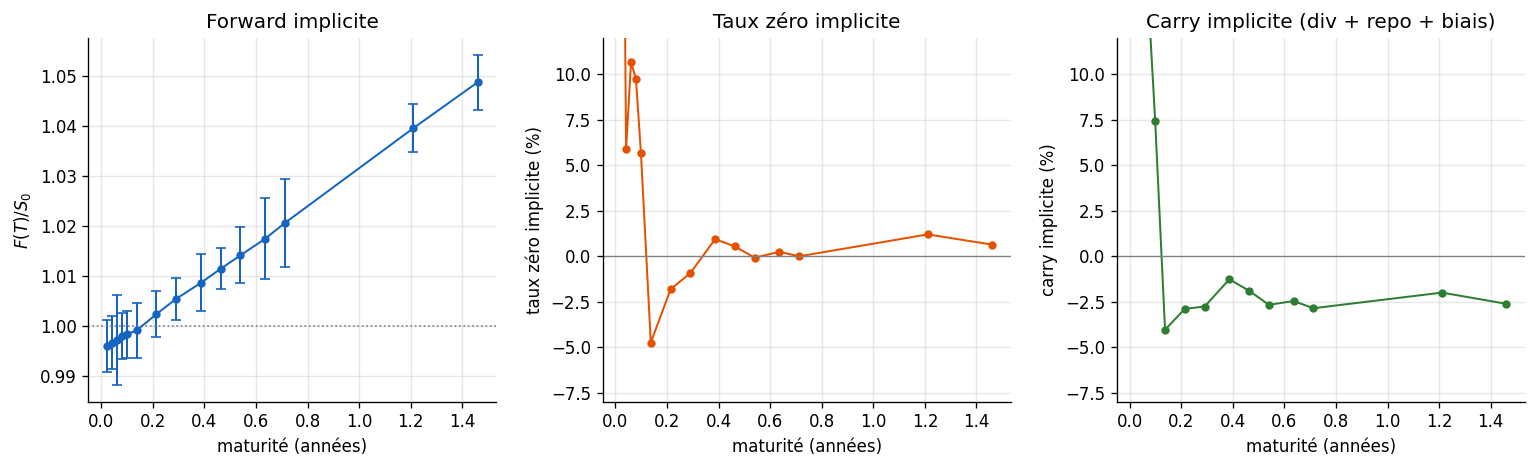

monotonie des discount factors : False


In [6]:

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

ax = axes[0]
ax.errorbar(tab.maturity, tab.forward / S0, yerr=tab.stderr_forward / S0,
            fmt='o-', color=C_HE, ms=4, capsize=3, lw=1.2)
ax.axhline(1.0, color='grey', ls=':', lw=1)
ax.set_xlabel('maturité (années)'); ax.set_ylabel('$F(T) / S_0$')
ax.set_title('Forward implicite')

ax = axes[1]
ax.plot(tab.maturity, tab.zero_rate * 100, 'o-', color=C_LV, ms=4, lw=1.2)
ax.axhline(0, color='grey', lw=0.8)
ax.set_xlabel('maturité (années)'); ax.set_ylabel('taux zéro implicite (%)')
ax.set_title('Taux zéro implicite')
ax.set_ylim(-8, 12)

ax = axes[2]
ax.plot(tab.maturity, tab.implied_carry * 100, 'o-', color=C_SK, ms=4, lw=1.2)
ax.axhline(0, color='grey', lw=0.8)
ax.set_xlabel('maturité (années)'); ax.set_ylabel('carry implicite (%)')
ax.set_title('Carry implicite (div + repo + biais)')
ax.set_ylim(-8, 12)
plt.tight_layout(); plt.show()

print("monotonie des discount factors :", curves.has_monotonic_discount_factors)



Le contraste entre les trois panneaux est le vrai enseignement de cette section.

Le forward est extrêmement bien identifié : une courbe lisse, croissante
d'environ 2.5% par an, avec des barres d'erreur de l'ordre de un ou deux dollars
sur un spot à 305. Normal : le forward est l'ordonnée du point où la droite
coupe l'axe, en plein milieu du nuage de points, là où les quotes sont serrées.

Le discount factor, lui, est un désastre aux maturités courtes : le taux zéro
implicite oscille entre -5% et +39% (hors graphe) avant de se calmer au-delà de
six mois. Ce n'est pas un bug, c'est de la géométrie : $D$ est la pente de la
droite, et sur une fenêtre de strikes de plus ou moins 15%, distinguer une pente
de -0.999 d'une pente de -0.995 demande une précision sur $C - P$ que le spread
bid-ask ne permet pas. À trois semaines, 10 points de base de taux valent moins
d'un cent sur la parité. Le discount factor peut même dépasser 1, et le builder
se contente de le signaler par un warning au lieu de planter.

S'ajoute le biais américain : la prime d'exercice anticipé des puts pousse
$C - P$ vers le bas, ce qui se lit comme un taux plus bas que le taux sans
risque réel. Le carry implicite (troisième panneau) absorbe tout ce que le
forward ne dit pas : dividendes attendus, coût d'emprunt du titre, et ce biais.

Un desk réagirait de deux façons : soit ancrer l'actualisation sur sa courbe de
funding et ne garder de la parité que le forward, soit assumer la mesure
auto-cohérente. On choisit la seconde : les mêmes courbes serviront à extraire
les vols implicites et à calibrer les modèles, donc toute erreur d'actualisation
se compense d'elle-même au repricing. Ces courbes ne prétendent pas mesurer
l'OIS, elles définissent la mesure de pricing dans laquelle les vanilles AAPL se
repricent exactement. C'est tout ce dont la suite a besoin.


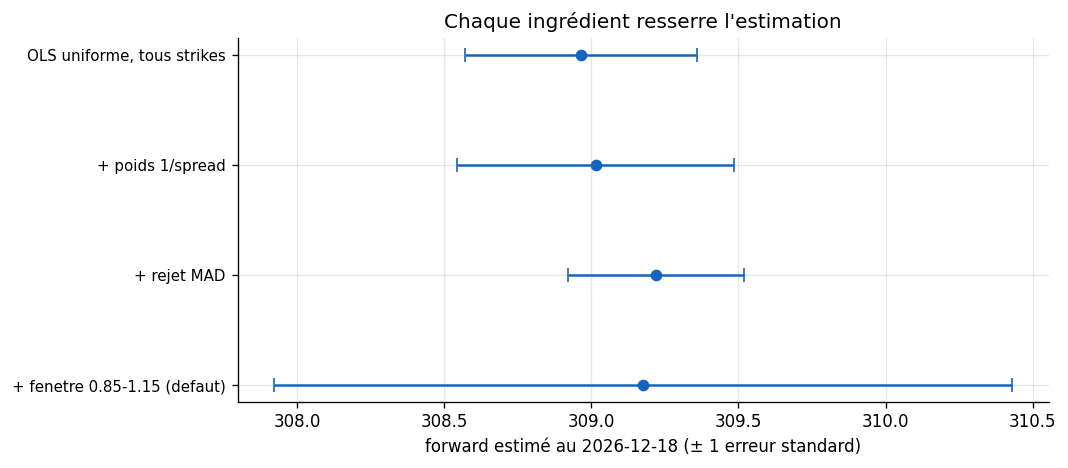

OLS uniforme, tous strikes             F =  308.97 ± 0.39   r = +2.71%   n = 43
+ poids 1/spread                       F =  309.01 ± 0.47   r = +2.66%   n = 43
+ rejet MAD                            F =  309.22 ± 0.30   r = +3.22%   n = 40
+ fenetre 0.85-1.15 (defaut)           F =  309.18 ± 1.25   r = +0.54%   n = 18


In [7]:

# Les choix du builder valent-ils le coup ? On rejoue la meme extraction sur une
# echeance liquide en degradant la config, et on compare le forward estime.
exp_test = date(2026, 12, 18)
T_test = DC.year_fraction(REF, exp_test)
configs = [
    ('OLS uniforme, tous strikes',
     dict(weighting=UniformWeights(), regression=WeightedLeastSquares(), strike_window=None)),
    ('+ poids 1/spread',
     dict(weighting=InverseSpreadWeights(), regression=WeightedLeastSquares(), strike_window=None)),
    ('+ rejet MAD',
     dict(weighting=InverseSpreadWeights(), regression=MADRejectionRegression(), strike_window=None)),
    ('+ fenetre 0.85-1.15 (defaut)',
     dict(weighting=InverseSpreadWeights(), regression=MADRejectionRegression(),
          strike_window=StrikeWindow(0.85, 1.15))),
]
rows = []
for label, kwargs in configs:
    b = PutCallParityCurveBuilder(DC, LogLinearInterpolator1D(), LogLinearInterpolator1D(), **kwargs)
    d = b.build(quotes, snap.spot, REF).diagnostics[T_test]
    rows.append((label, d.forward, d.stderr_forward, d.zero_rate, d.n_quotes_used))

fig, ax = plt.subplots(figsize=(9, 4))
labels = [r[0] for r in rows]
ax.errorbar([r[1] for r in rows], range(len(rows)), xerr=[r[2] for r in rows],
            fmt='o', color=C_HE, capsize=4, ms=6)
ax.set_yticks(range(len(rows))); ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel(f'forward estimé au {exp_test} (± 1 erreur standard)')
ax.set_title('Chaque ingrédient resserre l\'estimation')
plt.tight_layout(); plt.show()

for label, F, se, zr, n in rows:
    print(f"{label:38s} F = {F:7.2f} ± {se:.2f}   r = {zr:+.2%}   n = {n}")



Les estimations centrales bougent peu (la parité est robuste), mais l'erreur
standard fond à chaque étape : la pondération écrase le bruit des ailes, le
rejet MAD retire les quotes stagnantes, la fenêtre élimine la zone où l'exercice
anticipé fausse la relation. On garde la configuration complète pour la suite.



## 2. La surface de vol implicite, et son lissage SVI

On peut maintenant inverser les prix en vols implicites, puisque forward et
discount sont connus. Deux conventions de place s'appliquent :

- par strike, on n'utilise que l'option hors de la monnaie : put si $K < F$,
  call sinon. Les options dans la monnaie ont un delta proche de 1, presque
  toute leur valeur est intrinsèque, et leur vol implicite est un ratio
  bruit/vega épouvantable. C'est aussi là que la prime américaine est la plus
  forte : les ignorer tue deux problèmes d'un coup ;
- on ne garde que les échéances qui ont passé la section 1 avec de bons
  diagnostics, assez de quotes, et un espacement suffisant entre piliers.

Ce dernier critère vient d'un problème qu'on a réellement rencontré en écrivant
ce notebook : les weeklies à deux ou trois semaines ont peu de strikes, des
ailes très pentues, et deux piliers quasi superposés créent des zones où la
variance totale décroît localement en maturité. Dupire divise par là (on le
verra en section 3), donc autant assainir dès maintenant. Les critères sont
programmatiques, pour que le notebook survive à un rafraîchissement du CSV.


In [8]:

sel = tab[(tab.n_quotes_used >= 10)      # assez de quotes apres nettoyage
          & (tab.r_squared > 0.999)      # parite propre
          & (tab.maturity >= 0.10)       # weeklies courtes ecartees (bruit, EEP)
          & (tab.maturity <= 1.30)]      # au-dela, l'open interest s'assèche

# espacement minimal : chaque pilier doit etre au moins 30% plus long que le
# precedent, pour ne pas empiler des echeances quasi superposees.
kept, last_T = [], 0.0
for idx, row in sel.iterrows():
    if row.maturity >= 1.3 * last_T:
        kept.append(idx)
        last_T = row.maturity
sel = sel.loc[kept]
print("échéances retenues pour la surface :")
print(sel[['maturity_date', 'maturity', 'n_quotes_used', 'forward', 'r_squared']]
      .to_string(index=False))


échéances retenues pour la surface :
maturity_date  maturity  n_quotes_used    forward  r_squared
   2026-08-21  0.136986             17 305.405429   0.999771
   2026-09-18  0.213699             18 306.402406   0.999829
   2026-10-16  0.290411             17 307.338481   0.999865
   2026-11-20  0.386301             18 308.318505   0.999745
   2027-01-15  0.539726             19 310.001830   0.999744
   2027-09-17  1.210959             17 317.782018   0.999843


2026-08-21 : 29 vols implicites, ATM ~ 27.0%
2026-09-18 : 30 vols implicites, ATM ~ 27.0%


2026-10-16 : 29 vols implicites, ATM ~ 26.3%


2026-11-20 : 30 vols implicites, ATM ~ 27.5%
2027-01-15 : 32 vols implicites, ATM ~ 26.3%


2027-09-17 : 36 vols implicites, ATM ~ 27.6%


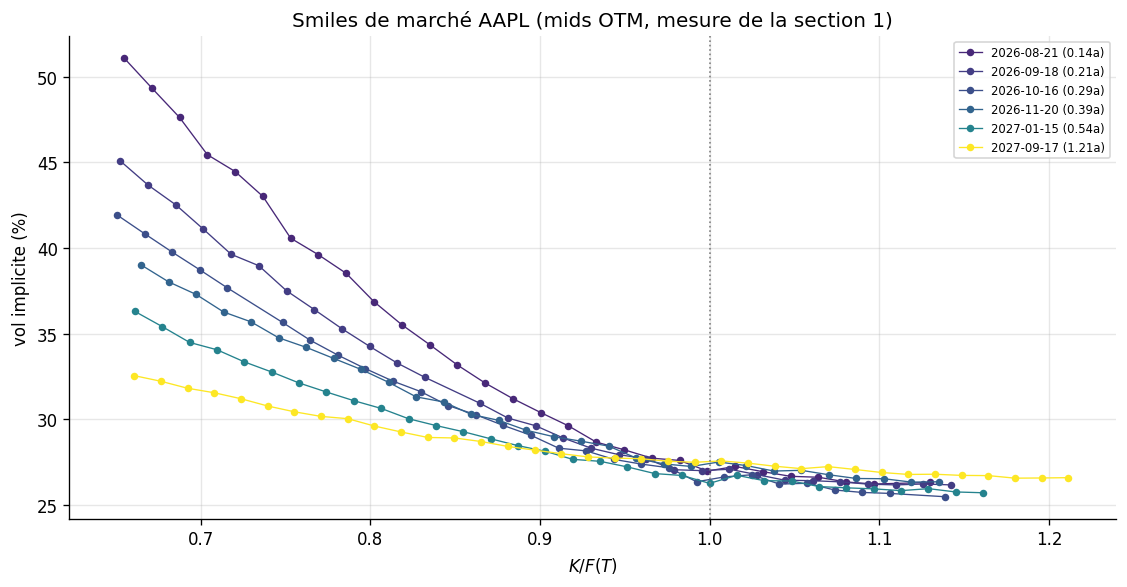

In [9]:

und = Underlying('AAPL', snap.spot, fwd)          # underlying de reference (sans vol)
ivc = ImpliedVolCalculator(disc)

smiles, iv_by_exp = [], {}
for _, row in sel.iterrows():
    T, F, exp = row.maturity, row.forward, row.maturity_date
    exp_quotes = [q for q in quotes
                  if q.maturity_date == exp and 0.65 * F <= q.strike <= 1.45 * F]
    Ks = np.array([q.strike for q in exp_quotes])
    mids = np.array([q.put_mid if q.strike < F else q.call_mid for q in exp_quotes])
    insts = [EuropeanOption(und, q.strike, REF, exp,
                            OptionType.PUT if q.strike < F else OptionType.CALL)
             for q in exp_quotes]
    ivs = ivc.calculate_implied_vol(insts, mids)
    ok = np.isfinite(ivs) & (ivs > 0.01) & (ivs < 2.0)   # inversions ratees ecartees
    smiles.append(VolSmile(Ks[ok], ivs[ok], LogLinearInterpolator1D(), exp, AbsoluteStrike()))
    iv_by_exp[exp] = (Ks[ok], ivs[ok], T, F)
    print(f"{exp} : {ok.sum():2d} vols implicites, ATM ~ {ivs[ok][np.argmin(np.abs(Ks[ok]-F))]:.1%}")

fig, ax = plt.subplots(figsize=(9.5, 5))
cmap = plt.get_cmap('viridis')
T_max = max(v[2] for v in iv_by_exp.values())
for exp, (Ks, ivs, T, F) in iv_by_exp.items():
    ax.plot(Ks / F, ivs * 100, 'o-', ms=3.5, lw=0.8, color=cmap(T / T_max),
            label=f'{exp} ({T:.2f}a)')
ax.axvline(1.0, color='grey', ls=':', lw=1)
ax.set_xlabel('$K / F(T)$'); ax.set_ylabel('vol implicite (%)')
ax.set_title('Smiles de marché AAPL (mids OTM, mesure de la section 1)')
ax.legend(fontsize=7)
plt.tight_layout(); plt.show()



Le marché a la tête attendue pour un single name tech : un skew négatif net, des
ailes de put chères, un smile qui s'aplatit avec la maturité, et un niveau ATM
autour de 26 à 28%. On voit aussi le bruit : les points ne s'alignent pas
parfaitement, certains sortent visiblement de la file.

Interpoler ces points directement (spline, RBF) recopierait le bruit dans la
surface, et Dupire prendrait ensuite deux dérivées de ce bruit. On lisse donc
chaque échéance avec une paramétrisation SVI (celle du notebook EQ02) :

$$w(k) = a + b\left(\rho (k - m) + \sqrt{(k-m)^2 + \sigma^2}\right),
\qquad k = \ln(K/F)$$

Cinq paramètres par échéance, une forme qui ne sait produire que des smiles
raisonnables, la contrainte papillon de Gatheral intégrée à la calibration, et
des dérivées analytiques exactement là où Dupire en aura besoin. Entre les
piliers, la variance totale est interpolée linéairement en maturité. C'est le
compromis desk classique : on accepte quelques points de base d'écart de fit en
échange d'une surface dérivable et sans arbitrage butterfly.


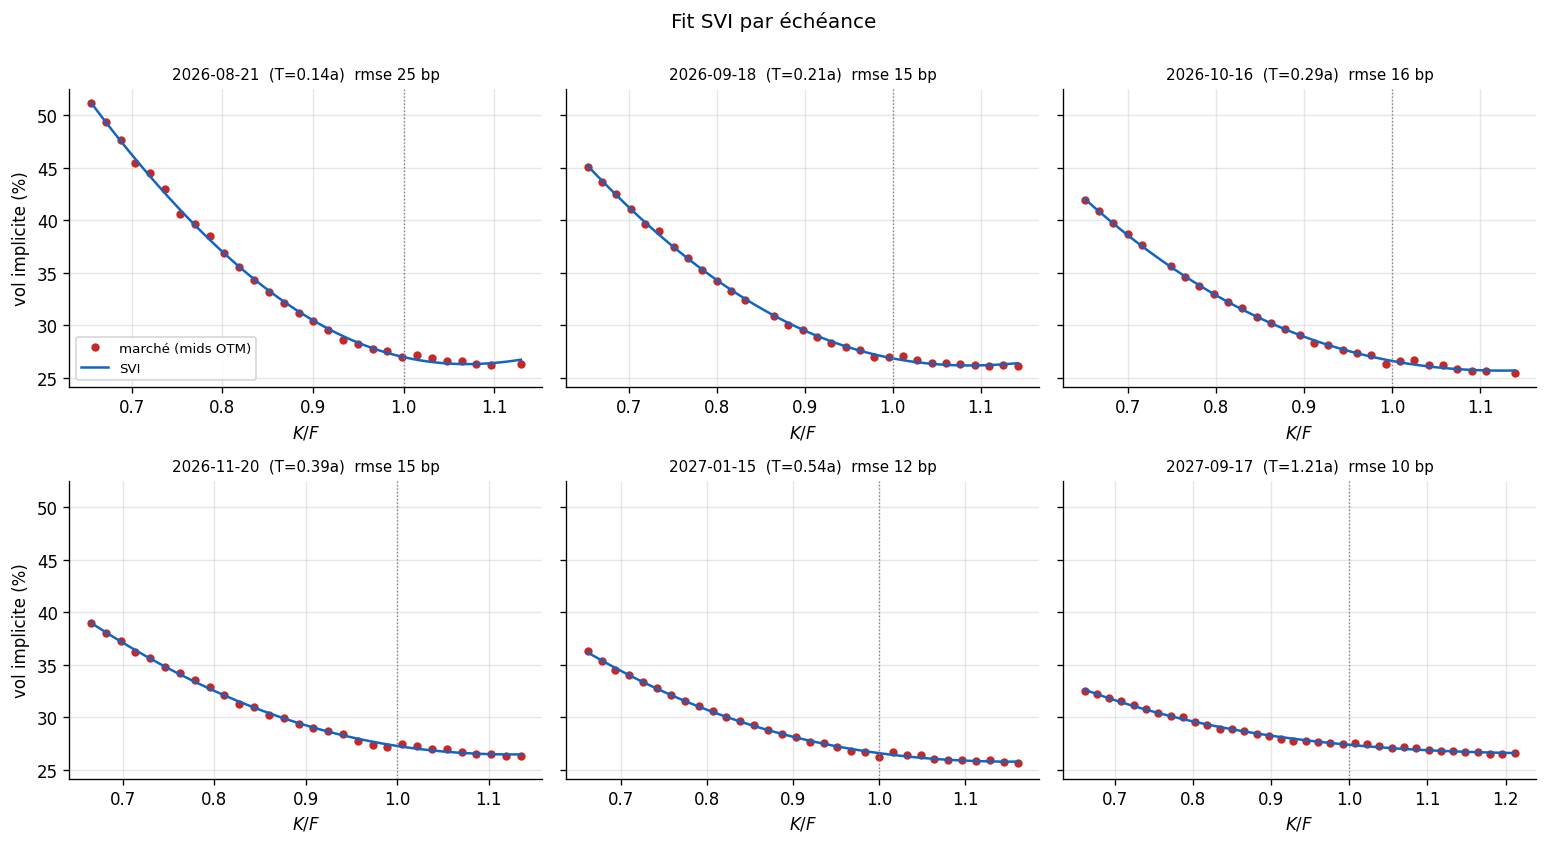

In [10]:

surface = VolSurface(smiles, REF, DC, SVIInterpolator(fwd), forward_curve=fwd)
surface.calibrate_interpolator()

expiries = list(iv_by_exp)
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=True)
for ax, exp in zip(axes.flat, expiries):
    Ks, ivs, T, F = iv_by_exp[exp]
    K_line = np.linspace(Ks.min(), Ks.max(), 120)
    ax.plot(Ks / F, ivs * 100, 'o', ms=4, color=C_MKT, label='marché (mids OTM)')
    ax.plot(K_line / F, surface.vol(K_line, T) * 100, color=C_HE, lw=1.5, label='SVI')
    err_bp = (surface.vol(Ks, T) - ivs) * 1e4
    ax.set_title(f'{exp}  (T={T:.2f}a)  rmse {np.sqrt(np.mean(err_bp**2)):.0f} bp',
                 fontsize=9)
    ax.axvline(1.0, color='grey', ls=':', lw=0.8)
    ax.set_xlabel('$K/F$')
axes[0, 0].set_ylabel('vol implicite (%)'); axes[1, 0].set_ylabel('vol implicite (%)')
axes[0, 0].legend(fontsize=8)
plt.suptitle('Fit SVI par échéance', y=1.00)
plt.tight_layout(); plt.show()


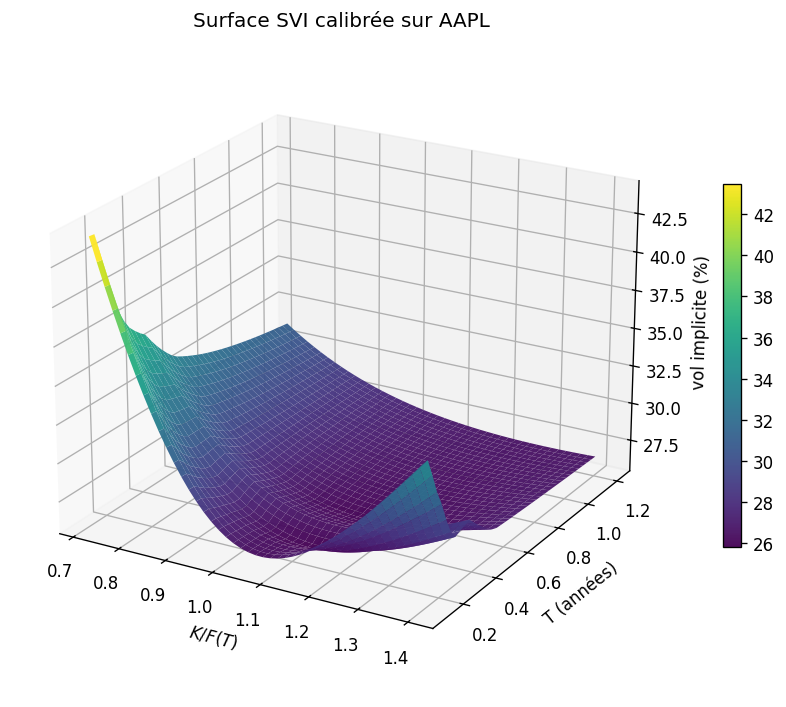

In [11]:

# La surface complete, vue en 3D dans la zone ou on l'utilisera.
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

T_grid = np.linspace(0.10, 1.21, 40)
m_grid = np.linspace(0.72, 1.40, 45)
IV = np.array([[float(surface.vol(m * fwd.forward(T), T)) for m in m_grid] for T in T_grid])

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
Mm, Tt = np.meshgrid(m_grid, T_grid)
surf = ax.plot_surface(Mm, Tt, IV * 100, cmap='viridis', edgecolor='none', alpha=0.95)
ax.set_xlabel('$K/F(T)$'); ax.set_ylabel('T (années)'); ax.set_zlabel('vol implicite (%)')
ax.set_title('Surface SVI calibrée sur AAPL')
ax.view_init(elev=22, azim=-60)
fig.colorbar(surf, shrink=0.55)
plt.tight_layout(); plt.show()



Le fit tient en 10 à 30 points de base de RMSE par échéance, avec les plus gros
écarts sur les échéances courtes (où le bruit de mid pèse le plus cher en vol) et
dans les ailes. C'est l'ordre de grandeur du spread bid-ask exprimé en vol : on
ne peut pas faire beaucoup mieux sans commencer à fitter du bruit. La surface 3D
est propre, le skew se relâche doucement avec la maturité. On a maintenant un
objet dérivable : Dupire peut entrer en scène.



## 3. La vol locale de Dupire, et ses fragilités sur données réelles

La formule de Dupire (variante de Gatheral en variance totale, notebook EQ02)
transforme la surface implicite en une surface de vol locale :

$$\sigma_{loc}^2(K, t) =
\frac{\partial_T w + \mu\,\partial_y w}
{1 - \frac{y}{w}\partial_y w + \frac{1}{4}\left(-\frac{1}{4} - \frac{1}{w} +
\frac{y^2}{w^2}\right)(\partial_y w)^2 + \frac{1}{2}\partial_y^2 w}$$

avec $w = \sigma^2 T$ la variance totale et $y = \ln(K/F)$. Le numérateur exige
que la variance totale croisse en maturité (pas d'arbitrage calendaire), le
dénominateur qu'il n'y ait pas d'arbitrage butterfly. Sur une surface générée
par un modèle, ces conditions sont gratuites. Sur une surface fittée sur du
bruit de marché, elles sont exactement ce qui casse en premier : c'est pour cela
qu'on a écarté les weeklies superposées en section 2 (leur tension calendaire
rendait le numérateur négatif entre deux piliers courts).

Avant toute simulation, on scanne donc la grille.


lignes en échec (arbitrage butterfly) : 0 | NaN (arbitrage calendaire) : 0


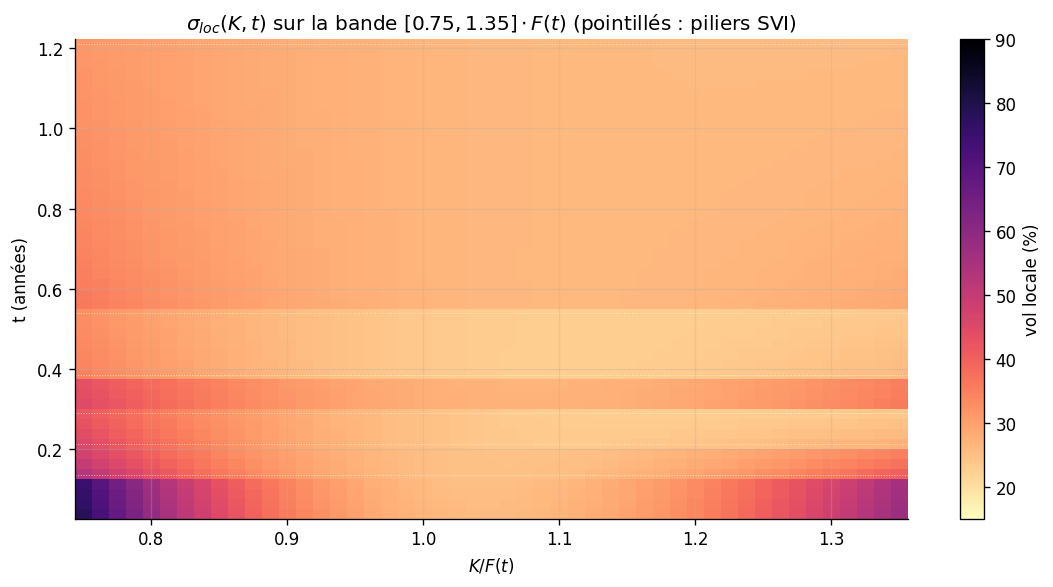

t=0.06 : sigma_loc(0.75F)=77%  ATM=26%  sigma_loc(1.35F)=57%
t=0.25 : sigma_loc(0.75F)=43%  ATM=25%  sigma_loc(1.35F)=25%
t=0.75 : sigma_loc(0.75F)=34%  ATM=27%  sigma_loc(1.35F)=27%


In [12]:

lv_raw = LocalVolModel(disc)

t_grid = np.linspace(0.04, 1.21, 48)
m_grid_lv = np.linspace(0.75, 1.35, 49)
LOC = np.full((len(t_grid), len(m_grid_lv)), np.nan)
n_bad = 0
for i, t in enumerate(t_grid):
    F_t = fwd.forward(t)
    try:
        LOC[i] = lv_raw.sigma_loc(m_grid_lv * F_t, t, surface, fwd)
    except ValueError:
        n_bad += 1
print("lignes en échec (arbitrage butterfly) :", n_bad,
      "| NaN (arbitrage calendaire) :", int(np.sum(~np.isfinite(LOC))))

fig, ax = plt.subplots(figsize=(9.5, 5))
pc = ax.pcolormesh(m_grid_lv, t_grid, LOC * 100, cmap='magma_r', shading='auto',
                   vmin=15, vmax=90)
for T_p in surface.maturities:
    ax.axhline(T_p, color='white', ls=':', lw=0.6, alpha=0.6)
ax.set_xlabel('$K / F(t)$'); ax.set_ylabel('t (années)')
ax.set_title('$\\sigma_{loc}(K, t)$ sur la bande $[0.75, 1.35] \\cdot F(t)$ '
             '(pointillés : piliers SVI)')
plt.colorbar(pc, label='vol locale (%)')
plt.tight_layout(); plt.show()

for t in (0.06, 0.25, 0.75):
    v = lv_raw.sigma_loc(np.array([0.75, 1.0, 1.35]) * fwd.forward(t), t, surface, fwd)
    print(f"t={t:.2f} : sigma_loc(0.75F)={v[0]:.0%}  ATM={v[1]:.0%}  sigma_loc(1.35F)={v[2]:.0%}")



Sur cette bande la grille est saine : pas de NaN, pas de dénominateur négatif.
Mais regardez les valeurs : la vol locale ATM vit tranquillement autour de 25%,
alors qu'à maturité courte l'aile de put dépasse 70%. C'est la mécanique de
Dupire qui veut ça (le skew court se paie en vol locale très pentue), et c'est
aussi une menace pour le Monte Carlo : une trajectoire qui part dans l'aile y
trouve une vol énorme, diffuse encore plus loin, et finit dans la zone
extrapolée du SVI où le dénominateur peut devenir négatif. En pratique, la
première tentative de simulation de ce notebook a explosé exactement comme ça,
sur une trajectoire tombée à 20% du spot en quelques pas.

La réponse standard est de borner le domaine : hors de la bande calibrée, la
vol locale est prolongée à plat au niveau du bord. En dehors de la zone où on a
des quotes, on n'a de toute façon aucune information, et une extrapolation
constante est un choix aussi défendable que ce que dirait le SVI extrapolé.
On encapsule ça dans une petite sous-classe.


In [13]:

class ClampedLocalVol(LocalVolModel):
    # Vol locale evaluee au strike borne dans [lo, hi] * F(t) : extrapolation
    # plate hors de la bande calibree, la diffusion reste libre.
    def __init__(self, discount_curve, band=(0.75, 1.35)):
        super().__init__(discount_curve)
        self._band = band

    def sigma_loc(self, S, t, vol_surface, forward_curve):
        F_t = forward_curve.forward(t)
        S_clamped = np.clip(S, self._band[0] * F_t, self._band[1] * F_t)
        return super().sigma_loc(S_clamped, t, vol_surface, forward_curve)


class TerminalSpots(EuropeanOption):
    # Payoff = S_T par trajectoire : une seule simulation reprice tous les
    # strikes d'une echeance. La grille dense est necessaire a la diffusion
    # a vol locale (EuropeanOption ne simule qu'un pas sinon).
    def __init__(self, *args, n_steps=60, **kwargs):
        super().__init__(*args, **kwargs)
        self._n = n_steps

    def simulation_times(self, ref, dc):
        T = dc.year_fraction(ref, self.maturity_date)
        return list(np.linspace(T / self._n, T, self._n))

    def payoff(self, paths):
        return paths[:, -1]


lv = ClampedLocalVol(disc)
und_lv = Underlying('AAPL', snap.spot, fwd, surface)   # underlying complet pour le MC
print(lv)


LocalVolModel(discount=DiscountCurve(n_pillars=15, ref=2026-07-02))


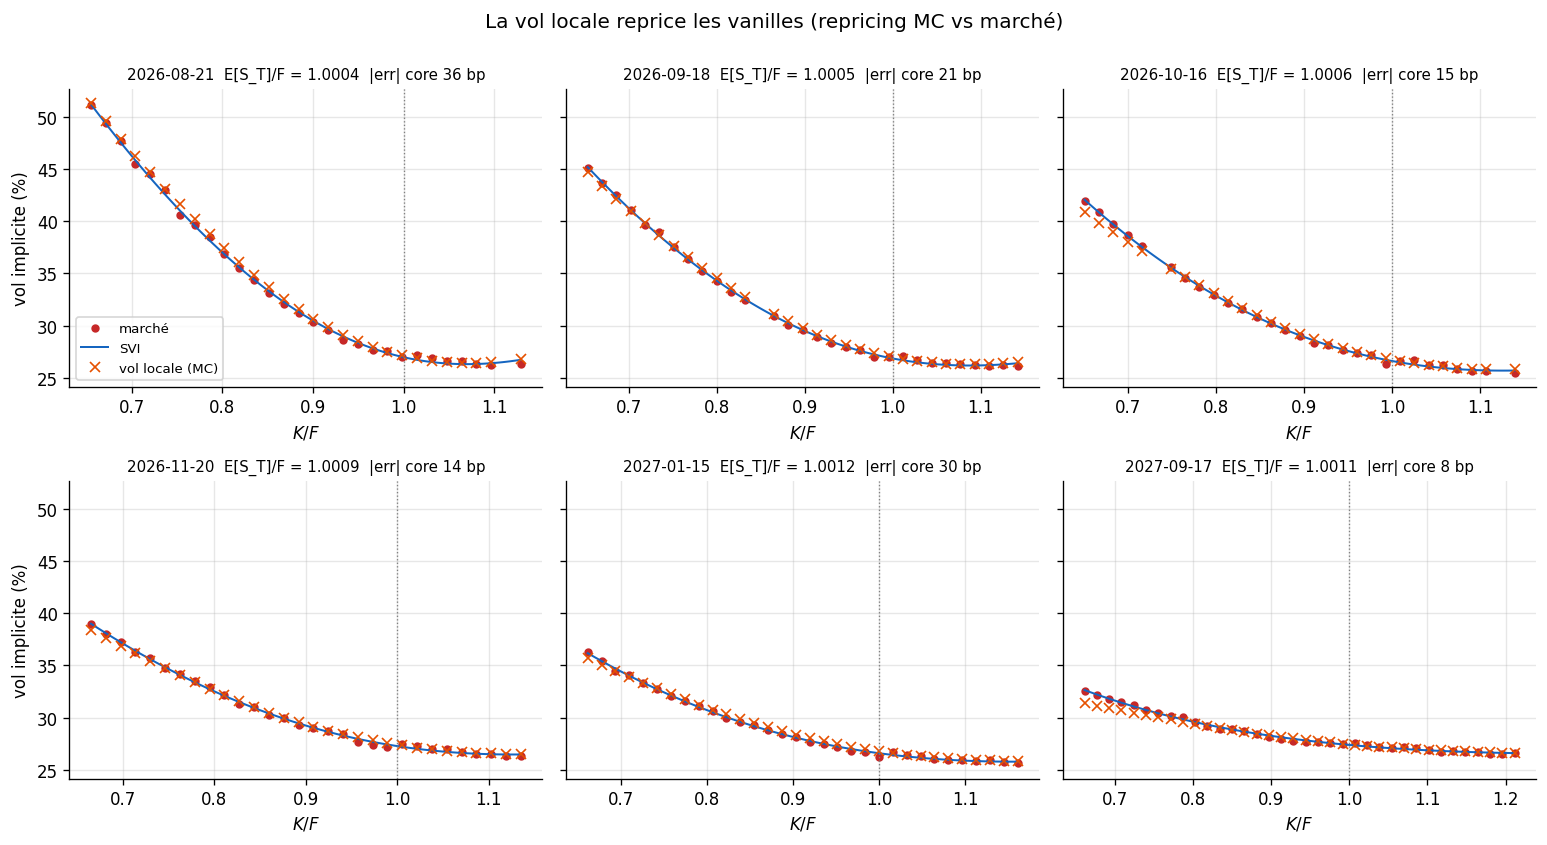

In [14]:

# Repricing : pour chaque echeance, une diffusion, tous les strikes, et on
# compare les vols implicites du modele au marche.
N_PATHS_REPRICE = 60_000
lv_err_by_exp = {}

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=True)
for ax, exp in zip(axes.flat, expiries):
    Ks, ivs, T, F = iv_by_exp[exp]
    df_T = disc.discount(T)
    ts = TerminalSpots(und_lv, F, REF, exp, OptionType.CALL,
                       n_steps=max(40, int(T * 120)))
    ST = lv.simulate(ts, N_PATHS_REPRICE, rng=np.random.default_rng(42)) / df_T
    calls = np.array([df_T * np.maximum(ST - K, 0).mean() for K in Ks])
    iv_mc = ivc.calculate_implied_vol(
        [EuropeanOption(und, float(K), REF, exp, OptionType.CALL) for K in Ks], calls)

    K_line = np.linspace(Ks.min(), Ks.max(), 120)
    ax.plot(Ks / F, ivs * 100, 'o', ms=4, color=C_MKT, label='marché')
    ax.plot(K_line / F, surface.vol(K_line, T) * 100, color=C_HE, lw=1.2, label='SVI')
    ax.plot(Ks / F, iv_mc * 100, 'x', ms=6, color=C_LV, label='vol locale (MC)')
    core = (Ks >= 0.85 * F) & (Ks <= 1.20 * F)
    err = (iv_mc - surface.vol(Ks, T)) * 1e4
    lv_err_by_exp[exp] = err[core]
    ax.set_title(f'{exp}  E[S_T]/F = {ST.mean()/F:.4f}  '
                 f'|err| core {np.nanmax(np.abs(err[core])):.0f} bp', fontsize=9)
    ax.axvline(1.0, color='grey', ls=':', lw=0.8)
    ax.set_xlabel('$K/F$')
axes[0, 0].set_ylabel('vol implicite (%)'); axes[1, 0].set_ylabel('vol implicite (%)')
axes[0, 0].legend(fontsize=8)
plt.suptitle('La vol locale reprice les vanilles (repricing MC vs marché)', y=1.00)
plt.tight_layout(); plt.show()



Trois vérifications d'un coup sur chaque échéance :

- la martingale : $E[S_T]/F$ colle à 1 à quelques points de base près, la
  diffusion respecte le forward extrait en section 1 ;
- le repricing : les croix orange retombent sur la courbe SVI à 20 ou 30 points
  de base près dans la zone centrale, soit l'erreur de Monte Carlo plus le
  résidu de discrétisation d'Euler. La boucle surface, Dupire, diffusion,
  inversion se referme ;
- dans les ailes lointaines, l'écart grossit (le clamp aplatit la vol locale au
  bord de bande). On le sait, on l'assume : c'est hors de la zone quotée.

La vol locale est donc calibrée. Par construction elle reprice tout le
continuum de vanilles : c'est sa raison d'être, et sa limite, comme on va le
voir en face d'Heston.



## 4. Heston sur la même surface

Deuxième modèle, philosophie opposée. Là où la vol locale absorbe la surface
entière dans une fonction $\sigma_{loc}(K, t)$ à dimension infinie, Heston n'a
que cinq paramètres pour tout dire :

$$dS_t = \mu S_t\,dt + \sqrt{v_t}\,S_t\,dW_t^S, \qquad
dv_t = \kappa(\theta - v_t)\,dt + \sigma_v \sqrt{v_t}\,dW_t^v, \qquad
d\langle W^S, W^v\rangle = \rho\,dt$$

Il ne pourra pas repricer chaque point : la calibration est un compromis, et
c'est voulu. On reprend le pipeline de calibration du notebook EQ01, avec deux
choix propres aux données réelles :

- la cible est la surface SVI, pas les mids bruts : on calibre sur du signal
  déjà lissé, aux mêmes points pour toutes les échéances (7 strikes réguliers en
  moneyness autour du forward). Calibrer sur les mids ajouterait du bruit sans
  rien apprendre de plus au modèle ;
- les instruments de calibration sont des calls : le moteur de Carr-Madan sort
  des prix de calls, et la vol implicite est identique pour un call et un put de
  même strike (parité, encore elle). L'erreur reste exprimée en vol, le seul
  langage comparable entre échéances.

Les bornes sont resserrées par rapport à EQ01 : $\rho \le 0$ (un skew equity
négatif), $\sigma_v \le 1.5$. Au-delà, la fonction caractéristique sort de sa
bande d'analyticité pour l'amortissement choisi (moment explosion, voir la mise
en garde d'EQ01 sur alpha) et l'optimiseur va explorer ces zones si on le
laisse faire : on l'a constaté, résidus non finis et calibration détruite.


In [15]:

cal_insts, cal_targets = [], []
for exp in expiries:
    Ks, ivs, T, F = iv_by_exp[exp]
    for frac in (0.85, 0.925, 0.975, 1.0, 1.025, 1.075, 1.15):
        K = float(Ks[np.argmin(np.abs(Ks - frac * F))])
        cal_insts.append(EuropeanOption(und, K, REF, exp, OptionType.CALL))
        cal_targets.append(float(surface.vol(K, T)))
cal_targets = np.array(cal_targets)
print(f"{len(cal_insts)} options de calibration ({len(expiries)} échéances x 7 strikes)")

fourier = FourierCarrMadanEngine(alpha=1.5, n=12, eta=0.25)
cost = ImpliedVolErrorCost(cal_insts, cal_targets, fourier, disc, HestonModel)

theta0 = np.array([2.0, 0.07, 0.6, -0.5, 0.07])            # kappa, theta, sigma_v, rho, v0
bounds = [(0.1, 8.0), (0.01, 0.30), (0.05, 1.50), (-0.99, 0.0), (0.01, 0.30)]

heston = calibrate(SciPyOLSOptimizer(), cost, theta0, bounds)

params = {k: float(getattr(heston, k)) for k in ('kappa', 'theta', 'sigma_v', 'rho', 'v0')}
residuals = cost(np.array(list(params.values())))
print("\nparamètres calibrés :")
for k, v in params.items():
    print(f"  {k:8s} = {v:+.4f}")
print(f"\nvol long terme sqrt(theta) = {np.sqrt(params['theta']):.1%}, "
      f"vol initiale sqrt(v0) = {np.sqrt(params['v0']):.1%}")
print(f"rmse = {np.sqrt(np.mean(residuals**2))*1e4:.0f} bp de vol, "
      f"max = {np.max(np.abs(residuals))*1e4:.0f} bp")
feller = 2 * params['kappa'] * params['theta'] - params['sigma_v']**2
print(f"condition de Feller 2*kappa*theta - sigma_v^2 = {feller:+.3f} "
      f"({'respectée' if feller > 0 else 'violée : v touche zéro, schéma full truncation requis'})")


42 options de calibration (6 échéances x 7 strikes)



paramètres calibrés :
  kappa    = +7.0422
  theta    = +0.0829
  sigma_v  = +1.4074
  rho      = -0.2752
  v0       = +0.0844

vol long terme sqrt(theta) = 28.8%, vol initiale sqrt(v0) = 29.1%
rmse = 27 bp de vol, max = 59 bp
condition de Feller 2*kappa*theta - sigma_v^2 = -0.813 (violée : v touche zéro, schéma full truncation requis)


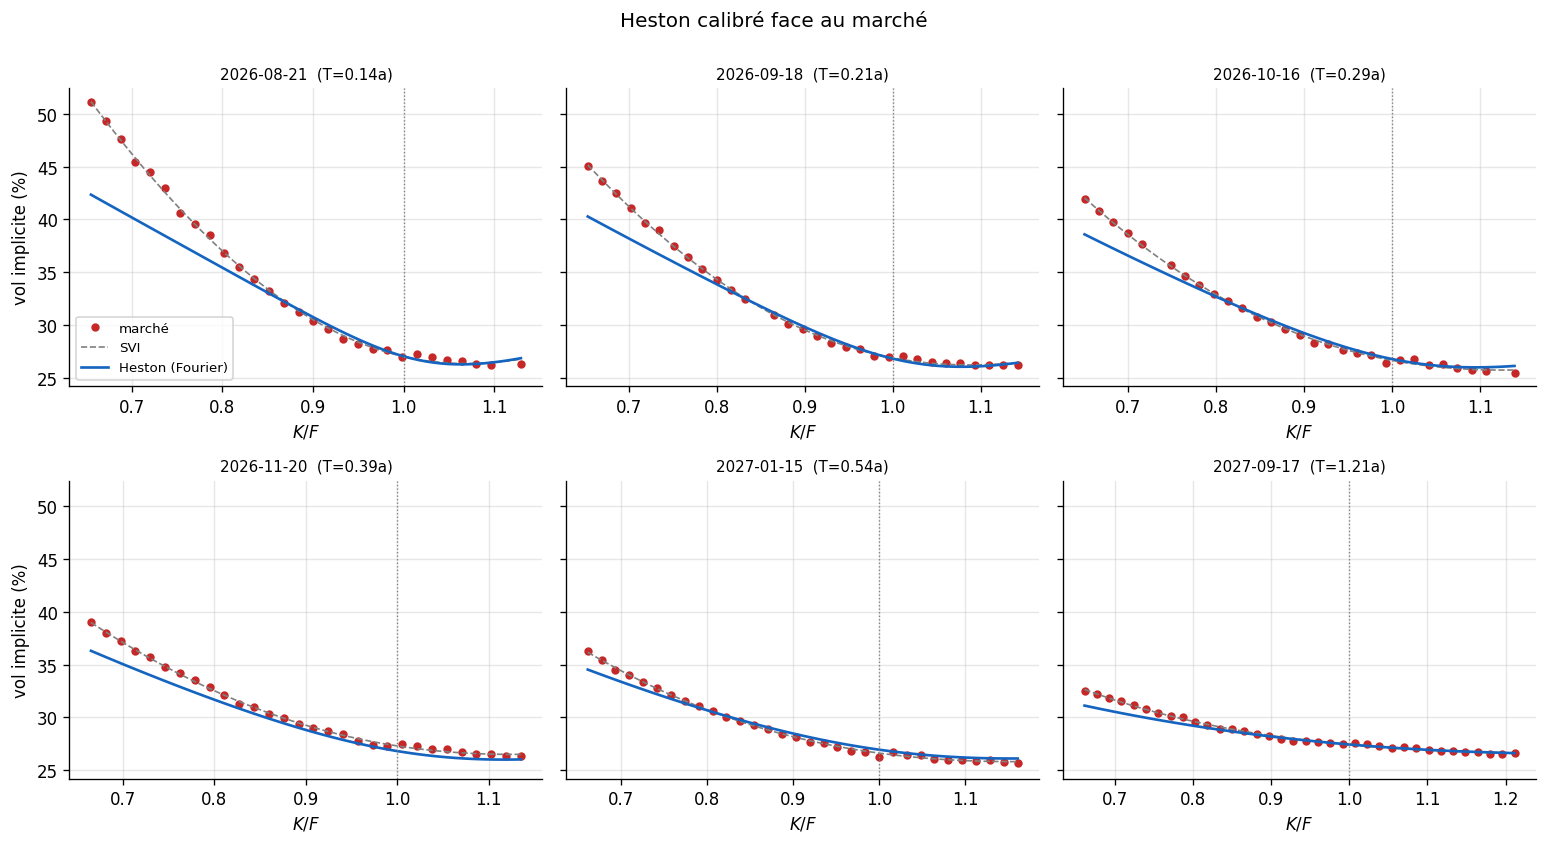

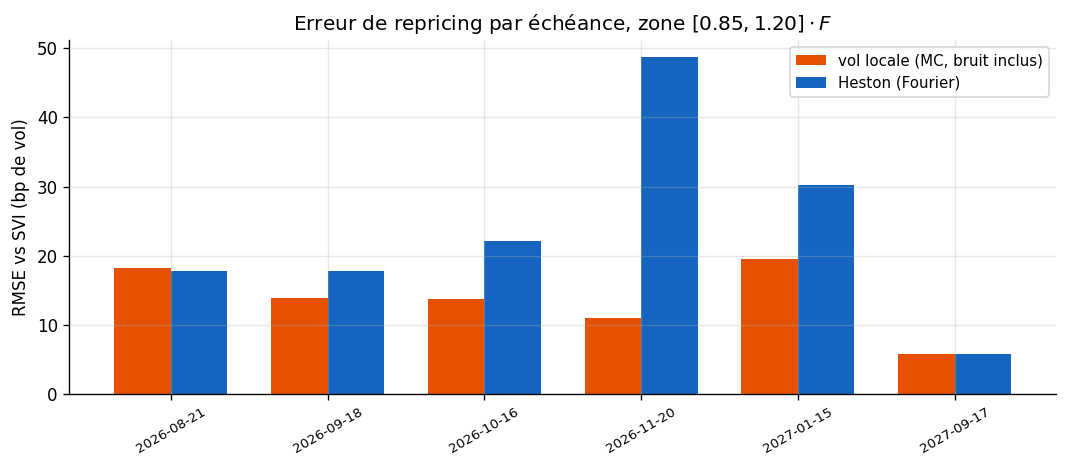

In [16]:

# Heston face au marche, echeance par echeance, et le score comparatif des
# deux modeles en RMSE de vol sur la zone centrale.
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=True)
he_err_by_exp = {}
for ax, exp in zip(axes.flat, expiries):
    Ks, ivs, T, F = iv_by_exp[exp]
    K_line = np.linspace(Ks.min(), Ks.max(), 60)
    calls_he = fourier.price([EuropeanOption(und, float(K), REF, exp, OptionType.CALL)
                              for K in K_line], heston)
    iv_he = ivc.calculate_implied_vol(
        [EuropeanOption(und, float(K), REF, exp, OptionType.CALL) for K in K_line], calls_he)
    ax.plot(Ks / F, ivs * 100, 'o', ms=4, color=C_MKT, label='marché')
    ax.plot(K_line / F, surface.vol(K_line, T) * 100, color='grey', lw=1, ls='--', label='SVI')
    ax.plot(K_line / F, np.array(iv_he) * 100, color=C_HE, lw=1.6, label='Heston (Fourier)')

    core = (Ks >= 0.85 * F) & (Ks <= 1.20 * F)
    calls_pts = fourier.price([EuropeanOption(und, float(K), REF, exp, OptionType.CALL)
                               for K in Ks[core]], heston)
    iv_he_pts = ivc.calculate_implied_vol(
        [EuropeanOption(und, float(K), REF, exp, OptionType.CALL) for K in Ks[core]], calls_pts)
    he_err_by_exp[exp] = (np.array(iv_he_pts) - surface.vol(Ks[core], T)) * 1e4
    ax.set_title(f'{exp}  (T={T:.2f}a)', fontsize=9)
    ax.axvline(1.0, color='grey', ls=':', lw=0.8)
    ax.set_xlabel('$K/F$')
axes[0, 0].set_ylabel('vol implicite (%)'); axes[1, 0].set_ylabel('vol implicite (%)')
axes[0, 0].legend(fontsize=8)
plt.suptitle('Heston calibré face au marché', y=1.00)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(expiries))
rmse_lv = [np.sqrt(np.nanmean(lv_err_by_exp[e]**2)) for e in expiries]
rmse_he = [np.sqrt(np.mean(he_err_by_exp[e]**2)) for e in expiries]
ax.bar(x - 0.18, rmse_lv, 0.36, color=C_LV, label='vol locale (MC, bruit inclus)')
ax.bar(x + 0.18, rmse_he, 0.36, color=C_HE, label='Heston (Fourier)')
ax.set_xticks(x)
ax.set_xticklabels([str(e) for e in expiries], rotation=30, fontsize=8)
ax.set_ylabel('RMSE vs SVI (bp de vol)')
ax.set_title('Erreur de repricing par échéance, zone $[0.85, 1.20] \\cdot F$')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()



Le fit Heston est honorable : quelques dizaines de points de base sur la zone
centrale, l'essentiel de l'écart logé aux échéances courtes. C'est le compromis
structurel du modèle : avec un seul jeu de paramètres, le skew court réclame une
vol-of-vol énorme et une corrélation très négative, pendant que le skew long en
demande moins. La calibration coupe la poire en deux : $\sigma_v$ élevé (1.4),
$\rho$ modérément négatif, $\kappa$ grand qui fait retomber la variance vite.
La condition de Feller est violée, comme presque toujours en equity : la
variance passe par zéro, le schéma de simulation devra l'encaisser (full
truncation, notebook EQ01).

Le bar chart résume la situation : la vol locale reprice par construction (son
erreur résiduelle est du bruit MC), Heston approxime. Sur les vanilles, la vol
locale gagne donc le match haut la main. La question intéressante est : et sur
autre chose que des vanilles ?



## 5. L'exotique : un call up-and-out

On price maintenant un produit que ni l'un ni l'autre modèle n'a vu en
calibration : un call 6 mois à la monnaie, désactivé si le spot franchit une
barrière haute (monitoring hebdomadaire), pour cinq niveaux de barrière de 105%
à 130% du spot.

Pourquoi ce produit est le bon juge de paix : son prix dépend de la probabilité
de toucher la barrière puis de finir dans la monnaie, autrement dit de la loi
jointe du chemin, pas seulement des lois marginales de $S_T$. Or les vanilles ne
contraignent que les marginales. Deux modèles d'accord sur toutes les vanilles
restent libres d'être en désaccord sur ce produit, et ils vont l'être.

Les deux modèles sont simulés par Monte Carlo sur la même grille hebdomadaire
(celle du monitoring), avec la même graine. Heston densifie sa grille en interne
(`discretize`, pas maximal d'un jour de bourse) pour que la variance CIR soit
correctement intégrée entre deux dates de monitoring. En contrôle, on price
aussi la vanille équivalente par les deux Monte Carlo, par Fourier et par la
formule de Black sur la vol SVI : quatre chiffres qui doivent coïncider.


In [17]:

mat_6m = REF + timedelta(days=182)
T_6m = DC.year_fraction(REF, mat_6m)
K_atm = round(S0 / 5) * 5.0
barrier_fracs = np.array([1.05, 1.10, 1.15, 1.20, 1.30])

heston_mc = heston.discretize(
    CIRDiscretizationSchemeEuler(EulerDiscretizationConvention.FULL_TRUNCATION),
    max_dt=1 / 252)
engine = MCEngine(n_paths=100_000, seed=42)

uo_calls = [BarrierOption(und_lv, K_atm, REF, mat_6m, Frequency.WEEKLY, OptionType.CALL,
                          BarrierType.OUT, BarrierDirection.UP, float(f * S0))
            for f in barrier_fracs]

px_lv = engine.price(uo_calls, lv)
px_he = engine.price(uo_calls, heston_mc)

# controle : la vanille 6M ATM par les quatre voies
vanilla = EuropeanOption(und_lv, K_atm, REF, mat_6m, OptionType.CALL)
far_barrier = BarrierOption(und_lv, K_atm, REF, mat_6m, Frequency.WEEKLY, OptionType.CALL,
                            BarrierType.OUT, BarrierDirection.UP, 100.0 * S0)
van_lv = engine.price([far_barrier], lv)[0]
van_he = engine.price([far_barrier], heston_mc)[0]
van_fourier = fourier.price([vanilla], heston)[0]
van_black = disc.discount(T_6m) * float(
    black_forward_price(fwd.forward(T_6m), K_atm, T_6m, surface.vol(K_atm, T_6m), True))
print(f"contrôle vanille K={K_atm:.0f}, 6M :")
print(f"  Black sur vol SVI     : {van_black:7.3f}")
print(f"  vol locale (MC)       : {van_lv:7.3f}")
print(f"  Heston (MC)           : {van_he:7.3f}")
print(f"  Heston (Fourier)      : {van_fourier:7.3f}")

print(f"\ncall up-and-out K={K_atm:.0f}, 6M, monitoring hebdomadaire :")
print(f"{'barrière':>10s} {'vol locale':>12s} {'Heston':>10s} {'écart':>8s}")
for f, pl, ph in zip(barrier_fracs, px_lv, px_he):
    print(f"{f:9.0%} {pl:12.3f} {ph:10.3f} {(ph - pl) / pl * 100:+7.1f}%")


contrôle vanille K=305, 6M :
  Black sur vol SVI     :  25.601
  vol locale (MC)       :  25.904
  Heston (MC)           :  25.888
  Heston (Fourier)      :  25.730

call up-and-out K=305, 6M, monitoring hebdomadaire :
  barrière   vol locale     Heston    écart
     105%        0.132      0.157   +18.8%
     110%        1.070      1.259   +17.6%
     115%        3.275      3.695   +12.8%
     120%        6.531      7.018    +7.5%
     130%       13.660     13.662    +0.0%


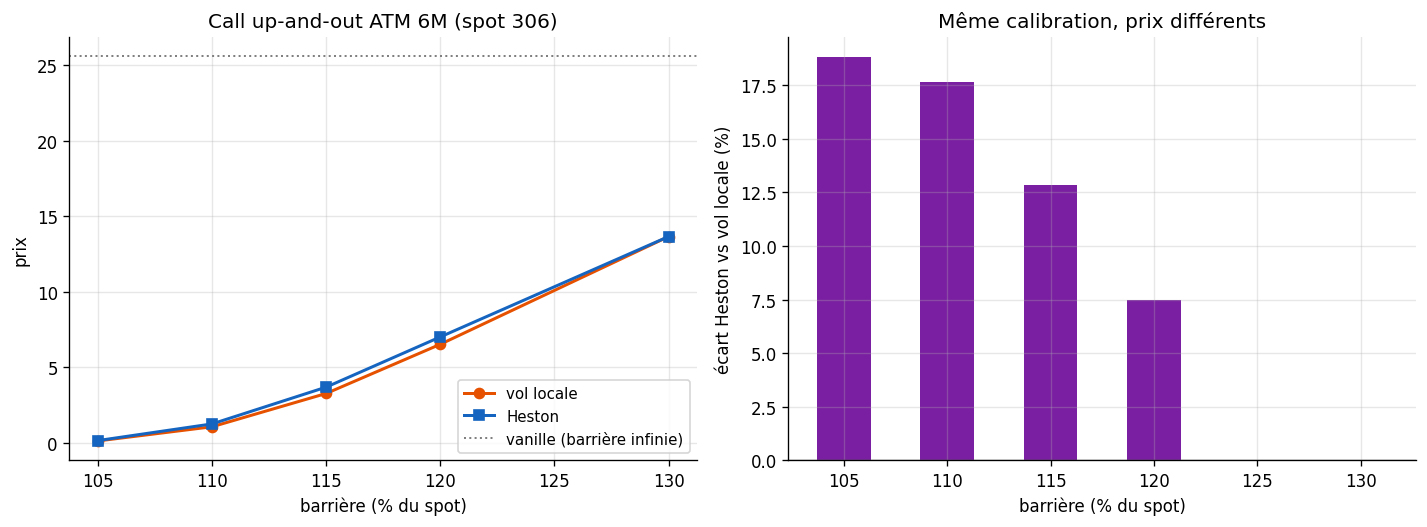

In [18]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(barrier_fracs * 100, px_lv, 'o-', color=C_LV, lw=1.8, label='vol locale')
ax1.plot(barrier_fracs * 100, px_he, 's-', color=C_HE, lw=1.8, label='Heston')
ax1.axhline(van_black, color='grey', ls=':', lw=1.2,
            label='vanille (barrière infinie)')
ax1.set_xlabel('barrière (% du spot)'); ax1.set_ylabel('prix')
ax1.set_title(f'Call up-and-out ATM 6M (spot {S0:.0f})')
ax1.legend(fontsize=9)

gap = (np.array(px_he) - np.array(px_lv)) / np.array(px_lv) * 100
ax2.bar(barrier_fracs * 100, gap, width=2.6, color='#7B1FA2')
ax2.axhline(0, color='grey', lw=0.8)
ax2.set_xlabel('barrière (% du spot)'); ax2.set_ylabel('écart Heston vs vol locale (%)')
ax2.set_title('Même calibration, prix différents')
plt.tight_layout(); plt.show()



Le contrôle passe : les quatre prix de vanille tiennent dans quelques cents,
soit l'erreur Monte Carlo cumulée à l'erreur de calibration Heston. On compare
donc bien les modèles, pas les moteurs.

Et sur la barrière, l'écart est là : Heston price la désactivante 8 à 19% plus
cher que la vol locale sur les barrières contraignantes, et l'écart s'éteint
quand la barrière s'éloigne (à 130% elle ne mord presque plus, on retombe sur la
vanille, que les deux modèles pricent pareil). Sur un produit qui se traite en
millions de notionnel, 15% de désaccord entre deux modèles tous les deux
parfaitement calibrés, c'est la définition même du risque de modèle.

Reste à comprendre le signe. L'intuition tient en une phrase : pour un
up-and-out, ce qui fait mal, c'est monter vers la barrière. Dans le modèle à vol
locale, une trajectoire qui monte vers 110 ou 115% du spot se retrouve dans une
zone où $\sigma_{loc}$ est faible (le skew descend à droite : regardez la
heatmap de la section 3). Le monde de la vol locale est un monde où les rallyes
se font en vol basse : une fois en haut, la trajectoire n'a plus l'énergie de
franchir, elle reste sous la barrière et meurt knockée ou pas selon quelques
centimes. Dans Heston, la vol au voisinage de la barrière n'est pas une fonction
du niveau de spot : c'est un état $v_t$ qui fluctue. Certaines trajectoires
montent en vol haute et se font désactiver franchement, d'autres montent en vol
basse et survivent avec un gros payoff. Cette dispersion des scénarios de vol,
la vol-of-vol, déplace la valeur : les trajectoires survivantes valent plus cher
que ce que le monde déterministe de la vol locale prévoit.

Dit autrement : les deux modèles sont d'accord sur la loi de $S_T$, pas sur la
manière dont la vol accompagne le spot en chemin. C'est précisément ce qu'on va
mesurer dans la dernière section.



## 6. Sticky strike, sticky delta : la dynamique du smile

Le vocabulaire vient des desks de dérivés :

- sticky strike : quand le spot bouge, la vol implicite à strike fixe ne bouge
  pas. Le smile est une nappe accrochée aux strikes, le spot glisse dessus ;
- sticky delta (ou sticky moneyness) : la vol implicite à moneyness fixe ne
  bouge pas. Le smile est accroché au ratio $K/S$ et se déplace avec le spot.

Aucun modèle ne porte ces étiquettes explicitement, mais chacun en implique
une. On la mesure avec l'expérience suivante : on déplace le spot de $\pm 5\%$
(en déplaçant proportionnellement toute la courbe forward, le carry ne change
pas), on redemande à chaque modèle la vol implicite du call à la monnaie
$K = S$ à 6 mois, et on regarde la pente.

- pour Heston, on reprice par Fourier au spot déplacé, paramètres inchangés :
  le processus $(v_t)$ ne sait pas où est le spot, son smile suit le forward ;
- pour la vol locale, on fige la surface $\sigma_{loc}(K, t)$ calibrée
  aujourd'hui, en strikes absolus, et on rediffuse depuis chaque spot déplacé
  (c'est le sens du modèle : la vol locale est une fonction du niveau, pas de
  la moneyness) ;
- la référence sticky strike se lit directement sur la surface d'aujourd'hui,
  au strike $K = S$ déplacé.


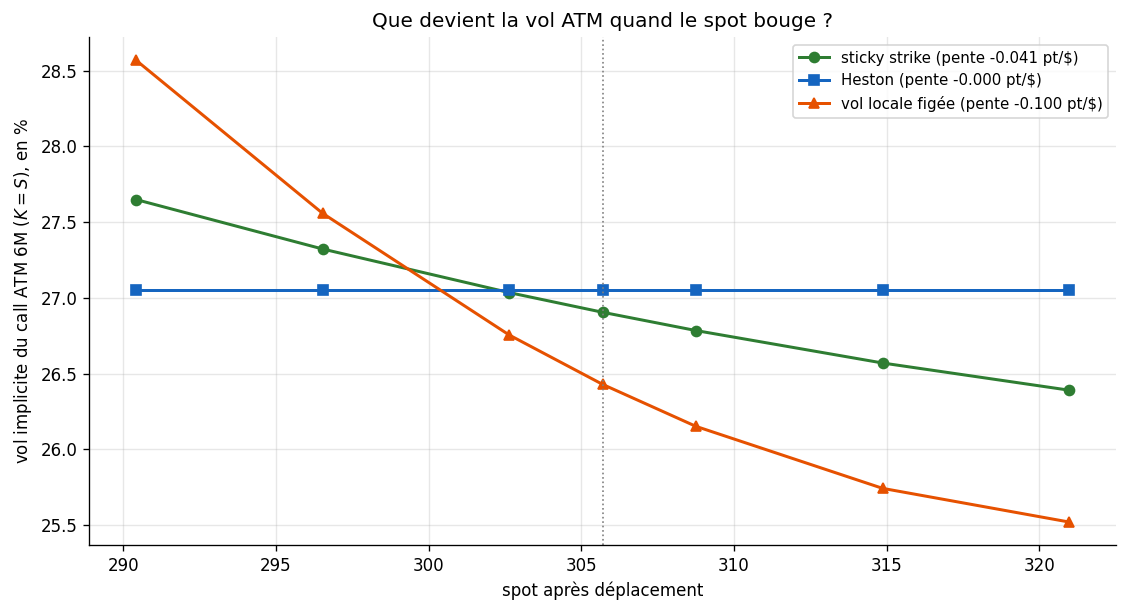

In [19]:

class FrozenLV(ClampedLocalVol):
    # Vol locale FIGEE aujourd'hui en (K, t) absolus : surface et forward du
    # jour, quel que soit le spot de depart de la diffusion.
    def __init__(self, discount_curve, surface_0, forward_0, band=(0.75, 1.35)):
        super().__init__(discount_curve, band)
        self._surface_0, self._forward_0 = surface_0, forward_0

    def sigma_loc(self, S, t, vol_surface, forward_curve):
        return super().sigma_loc(S, t, self._surface_0, self._forward_0)


def bumped_underlying(eps):
    # Spot et courbe forward deplaces proportionnellement (carry inchange).
    # Les piliers de la MarketForwardCurve sont figes : on reconstruit.
    spot_b = Quote(S0 * (1 + eps))
    fwd_b = MarketForwardCurve(spot_b, fwd.x, fwd.y * (1 + eps), LogLinearInterpolator1D())
    return Underlying('AAPL', spot_b, fwd_b, surface)


flv = FrozenLV(disc, surface, fwd)
df_6m = disc.discount(T_6m)
eps_grid = np.array([-0.05, -0.03, -0.01, 0.0, 0.01, 0.03, 0.05])
spots_b = S0 * (1 + eps_grid)

iv_sticky, iv_heston, iv_lv_frozen = [], [], []
for eps, S_b in zip(eps_grid, spots_b):
    und_b = bumped_underlying(eps)
    atm_b = EuropeanOption(und_b, float(S_b), REF, mat_6m, OptionType.CALL)
    # sticky strike : le smile d'aujourd'hui, lu au strike K = nouveau spot
    iv_sticky.append(float(surface.vol(float(S_b), T_6m)))
    # Heston : reprice Fourier au spot deplace, parametres inchanges
    iv_heston.append(float(ivc.calculate_implied_vol(
        [atm_b], fourier.price([atm_b], heston))[0]))
    # vol locale figee : rediffusion depuis le spot deplace
    ST_b = flv.simulate(TerminalSpots(und_b, float(S_b), REF, mat_6m, OptionType.CALL),
                        40_000, rng=np.random.default_rng(30)) / df_6m
    px_b = df_6m * np.maximum(ST_b - S_b, 0.0).mean()
    iv_lv_frozen.append(float(ivc.calculate_implied_vol([atm_b], [px_b])[0]))

iv_sticky, iv_heston, iv_lv_frozen = map(np.array, (iv_sticky, iv_heston, iv_lv_frozen))

def slope_pct_per_spot(y):
    return np.polyfit(spots_b, y, 1)[0] * 100

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.plot(spots_b, iv_sticky * 100, 'o-', color=C_SK, lw=1.8,
        label=f'sticky strike (pente {slope_pct_per_spot(iv_sticky):+.3f} pt/$)')
ax.plot(spots_b, iv_heston * 100, 's-', color=C_HE, lw=1.8,
        label=f'Heston (pente {slope_pct_per_spot(iv_heston):+.3f} pt/$)')
ax.plot(spots_b, iv_lv_frozen * 100, '^-', color=C_LV, lw=1.8,
        label=f'vol locale figée (pente {slope_pct_per_spot(iv_lv_frozen):+.3f} pt/$)')
ax.axvline(S0, color='grey', ls=':', lw=1)
ax.set_xlabel('spot après déplacement')
ax.set_ylabel('vol implicite du call ATM 6M ($K = S$), en %')
ax.set_title('Que devient la vol ATM quand le spot bouge ?')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()



Les trois pentes racontent trois mondes :

- la ligne verte est le smile d'aujourd'hui : sa pente est le skew, la vol ATM
  baisse quand on lit la surface plus à droite ;
- Heston est plat. Son smile flotte intégralement avec le forward : à moneyness
  fixe rien ne change, la vol ATM est la même à 290 qu'à 320. C'est un
  comportement sticky delta pur, et c'est ce qu'on observe en général sur les
  marchés d'indices en régime calme : le smile suit ;
- la vol locale figée descend deux fois plus vite que le skew. Résultat
  classique (la règle des "deux fois le skew" pour la dynamique ATM d'un modèle
  à vol locale) : quand le spot monte, la diffusion évolue dans la partie basse
  de la nappe $\sigma_{loc}$, et la vol ATM future plonge. Le smile de la vol
  locale ne suit pas le spot, il recule.

C'est exactement la mécanique qui séparait les prix de barrière en section 5,
vue sous un autre angle. Et elle a une conséquence très concrète : le delta.
Le prix d'un up-and-out dépend du spot ET de là où le smile sera si le spot
bouge. Deux hypothèses de dynamique donnent deux deltas, donc deux couvertures.


In [20]:

# Delta MC de l'up-and-out barriere 115% : bump du spot de +/-2%, meme graine
# de part et d'autre (differences communes), sous chacune des deux dynamiques.
B_115 = float(1.15 * S0)
h = 0.02
delta_engine = MCEngine(n_paths=100_000, seed=42)

deltas = {}
for name, model in (('vol locale figée', flv), ('Heston', heston_mc)):
    prices = []
    for eps in (-h, +h):
        und_b = bumped_underlying(eps)
        inst = BarrierOption(und_b, K_atm, REF, mat_6m, Frequency.WEEKLY, OptionType.CALL,
                             BarrierType.OUT, BarrierDirection.UP, B_115)
        prices.append(delta_engine.price([inst], model)[0])
    deltas[name] = (prices[1] - prices[0]) / (2 * h * S0)
    print(f"{name:18s} : px(-2%) = {prices[0]:6.3f}   px(+2%) = {prices[1]:6.3f}"
          f"   delta = {deltas[name]:+.4f}")

d_lv, d_he = deltas['vol locale figée'], deltas['Heston']
print(f"\nécart de delta : {abs(d_he - d_lv):.4f} en absolu, "
      f"soit {abs(d_he - d_lv) / abs(d_lv) * 100:.0f}% du delta vol locale")


vol locale figée   : px(-2%) =  3.364   px(+2%) =  3.150   delta = -0.0175


Heston             : px(-2%) =  3.745   px(+2%) =  3.585   delta = -0.0131

écart de delta : 0.0044 en absolu, soit 25% du delta vol locale



Le delta lui-même est presque nul, et c'est déjà une leçon : près de la
barrière, le gamma du produit change de signe, le call up-and-out se comporte
comme une position vendeuse de spot en haut de range. Mais surtout, les deux
modèles ne sont pas d'accord entre eux, avec un écart de l'ordre d'un quart de
la valeur du delta. Le trader qui couvre ce produit doit choisir sa dynamique
de smile, pas seulement son prix : se couvrir avec le delta vol locale quand le
marché se comporte de façon sticky delta, c'est saigner du P&L de rebalancement
tous les jours, même si le prix initial était juste.

C'est le mot de la fin sur le débat vol locale contre vol stochastique. La vol
locale est l'interpolateur parfait des vanilles d'aujourd'hui, mais sa
dynamique de smile est fausse (elle recule quand le marché suit). Heston fitte
moins bien la photo, mais le film est plus crédible. Sur un desk, le choix se
fait produit par produit, et les modèles de production mélangent souvent les
deux (local-stochastic vol) exactement pour réconcilier photo et film.



## 7. Ce qu'on retient, et ce qu'on a balayé sous le tapis

Le pipeline complet, sur des données qui n'ont rien demandé à personne :

| étape | méthode | verdict |
|---|---|---|
| courbes | parité put-call, régression robuste par échéance | forward excellent, discount bruité aux courtes |
| surface | mids OTM inversés puis SVI par échéance | 10 à 30 bp de RMSE |
| vol locale | Dupire sur SVI, bande bornée | reprice les vanilles (~20-30 bp + bruit MC) |
| Heston | 5 paramètres, cible SVI, Fourier | compromis honnête (~30-60 bp) |
| up-and-out | MC commun, grille et graine partagées | écarts jusqu'à ~19% entre modèles |
| dynamique | bump de spot, vol ATM et delta | Heston sticky delta, LV à contre-sens |

Les choix documentés en route, qui sont autant de limites :

- le biais américain n'est pas corrigé, seulement contenu (fenêtre ATM, mids
  OTM). Une dé-américanisation propre passerait par un arbre binomial par quote ;
- les dividendes discrets d'AAPL sont lissés dans une courbe forward continue.
  Pour du pricing de convertibles ou d'options courtes autour d'une date
  ex-dividende, il faudrait les modéliser en cash ;
- l'actualisation est la mesure auto-cohérente de la parité, pas une courbe de
  funding : parfait pour repricer des options AAPL, faux pour agréger avec
  d'autres books ;
- le monitoring de la barrière est hebdomadaire et discret. Un monitoring
  continu ferait baisser les deux prix (correction de Broadie-Glasserman-Kou
  en $e^{\pm 0.5826\,\sigma\sqrt{\Delta t}}$ sur la barrière) sans changer la
  conclusion sur l'écart ;
- le snapshot yfinance est du milieu de séance, sans nettoyage manuel : on a
  préféré montrer des filtres programmatiques qui encaissent, plutôt qu'un CSV
  retouché à la main.

La suite naturelle : un modèle local-stochastic vol (calibrer la fonction de
levier sur la surface, garder la vol-of-vol d'Heston), et le pricing des mêmes
barrières dedans. La photo et le film, enfin réconciliés.
